# Test to get this 'Csordas' subnetwork method working

Input test command for **"permuted MNIST**:

main.py -name transfer_sharing -task permuted_mnist -stop_after 30000 -mask_loss_weight 0.00128 -lr 0.01 -mask_init 2 -layer_sizes 800,800,64

In [1]:
import torch
import torchvision
import framework
import tasks
import os

path = "./save/cifar10/checkpoint/model-220011.pth"
test = torch.load(path, weights_only=False)

# Fake-run the test command to populate 'sys.argv'

import shlex
import sys

cmd = "main.py -name cifar10_one_mask_per_class -task cifar10_class_removal -stop_after 20000 -mask_loss_weight 3e-4 -mask_lr 1e-3 -step_per_mask 20000 -class_removal.keep_last_layer 1 -dropout 0.0 -cnn.dropout 0 -restore_pretrained ./save/cifar10/model_weights"
cmd_args = shlex.split(cmd)
sys.argv = cmd_args

print(cmd_args)

['main.py', '-name', 'cifar10_one_mask_per_class', '-task', 'cifar10_class_removal', '-stop_after', '20000', '-mask_loss_weight', '3e-4', '-mask_lr', '1e-3', '-step_per_mask', '20000', '-class_removal.keep_last_layer', '1', '-dropout', '0.0', '-cnn.dropout', '0', '-restore_pretrained', './save/cifar10/model_weights']


In [2]:
from main import register_args, load_weights, save_weights

training_helper = framework.helpers.TrainingHelper(
    wandb_project_name="modules",
    register_args=register_args, 
    extra_dirs=["export", "model_weights"])

def invalid_task_error(self):
    assert False, f"Invalid task: {training_helper.opt.task}"

constructors = {
    "tuple": tasks.TupleTask,
    "tuple_ff": tasks.TupleTaskFeedforward,
    "scan": tasks.ScanTask,
    "trafo_scan": tasks.TransformerScanTask,
    "addmul_ff": tasks.AddMulFeedforward,
    "addmul": tasks.AddMulTask,
    "cifar10_class_removal": tasks.Cifar10ClassRemovalTask,
    "cifar10_resnet_hp_class_removal": tasks.Cifar10ResnetHPClassRemovalTask,
    "cifar10_mask_stability": tasks.Cifar10MaskStabilityTask,
    "cifar10_grad_cos_distance": tasks.Cifar10GradCosDistanceTask,
    "permuted_mnist": tasks.PermutedMnistTask,
    "deepmind_math": tasks.DeepmindMathTask,
    "tuple_ff_copyweight": tasks.TupleFeedforwardCopyweightTask
}

task = constructors.get(training_helper.opt.task, invalid_task_error)(training_helper)

There is no more free GPUs. Allocating the one with least memory usage.
#########################
DROPOUT:
False
#########################
Found module parameters: ['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight']
Masking is applied to paramteres: {'features_0_weight', 'features_10_bias', 'features_3_weight', 'features_3_bias', 'out_layer_bias', 'features_6_weight', 'features_6_bias', 'features_10_weight', 'features_0_bias', 'out_layer_weight'}
Masking 390986 out of 390986 parameters (100.0 %)


/home/gulmar/miniconda3/envs/test_csordas/lib/python3.12/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


In [3]:
if training_helper.opt.restore_pretrained:
    assert not task.helper.opt.train_baseline
    load_weights(training_helper, task)
    if training_helper.opt.test_pretrained:
        training_helper.summary.log({f"load_validation/{k}": v for k, v in task.validate().items()})
    print("Done. Skipping training...")
else:
    if task.helper.opt.train_baseline:
        task.set_baseline_mode()

    task.train()

    print("Training finished. Saving model...")
    save_weights(training_helper, task)

/home/gulmar/Library/Projects/Csordas_modules/main.py:169: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(pretrained)


Loading pretrained weights from ./save/cifar10/model_weights/model.pth...


100%|██████████| 78/78 [00:00<00:00, 143.85it/s]


Validation accuracy on iid: 0.7698803659394793


100%|██████████| 78/78 [00:00<00:00, 297.29it/s]


Validation accuracy on train: 0.9890419221875942
Done. Skipping training...


In [4]:
if task.helper.opt.analysis.enable and not task.helper.opt.train_baseline:
    task.post_train_2()

100%|██████████| 78/78 [00:00<00:00, 282.59it/s]


Validation accuracy on iid: 0.7698803659394793


100%|██████████| 78/78 [00:00<00:00, 300.27it/s]


Validation accuracy on train: 0.9890419221875942
stage / mask_id: 0 / -1
Set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ----> Mask class: -1


/home/gulmar/miniconda3/envs/test_csordas/lib/python3.12/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


...

100%|██████████| 78/78 [00:00<00:00, 284.02it/s]


Validation accuracy on iid: 0.4092691263697597


100%|██████████| 63/63 [00:00<00:00, 271.00it/s]


Validation accuracy on train: 0.8239709746027775
Now mask step: 19990 (iter: 220000, start: 200010)


100%|██████████| 78/78 [00:00<00:00, 274.74it/s]


In [5]:
for i in range(len(task.model.masks)):
    print(f"Mask {i}: {task.model.masks[i].keys()}")

Mask 0: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
Mask 1: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
Mask 2: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
Mask 3: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
Mask 4: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 

In [ ]:
# step = 10 # Number of "layers" per 'mask-dict'
# loaded_masks = torch.nn.ModuleList([torch.nn.ParameterDict({layer_name: torch.nn.Parameter(mask_params) 
#  for (layer_name, _), (long_layer_name, mask_params) in zip(task.model.model_parameters.items(), list(test["model"].items())[step+i*step:i*step+step+step])
#  if task.mask_filter(layer_name)})
#  for i in range(task.get_n_masks())
#     ])

# task.model.masks = loaded_masks

100%|██████████| 78/78 [00:00<00:00, 253.94it/s]


Validation accuracy on iid: 0.4115813813210013


100%|██████████| 63/63 [00:00<00:00, 263.64it/s]


Validation accuracy on train: 0.8265982734893031


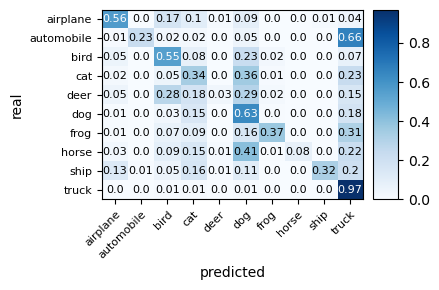

In [6]:
%matplotlib inline

import matplotlib.pyplot as plt

a = {f"validation/{k}": v for k, v in task.validate().items() if k.endswith("/confusion")}

a["validation/iid/confusion"].to_matplotlib()
plt.show()

In [7]:
task.validate().items()

100%|██████████| 78/78 [00:00<00:00, 266.66it/s]


Validation accuracy on iid: 0.4115813813210013


100%|██████████| 63/63 [00:00<00:00, 263.22it/s]

Validation accuracy on train: 0.8265982734893031


dict_items([('iid/loss', 5.175891927418259), ('iid/accuracy', 0.4115813813210013), ('iid/confusion', <framework.visualize.plot.ConfusionMatrix object at 0x7f1db7fea7b0>), ('train/loss', 0.86225708913821), ('train/accuracy', 0.8265982734893031), ('train/confusion', <framework.visualize.plot.ConfusionMatrix object at 0x7f1dba3d25a0>), ('mean_accuracy', 0.6190898274051522), ('mean_loss', 3.0190745082782344)])

In [8]:
stage = 0
task.model.set_active(stage)
test, b = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid) 

confusion = test.confusion.type(torch.float32)
confusion = (confusion / confusion.sum(dim=0, keepdim=True)).transpose(1, 0)
if stage == 0:
    confusion_ref = confusion

100%|██████████| 78/78 [00:00<00:00, 267.71it/s]


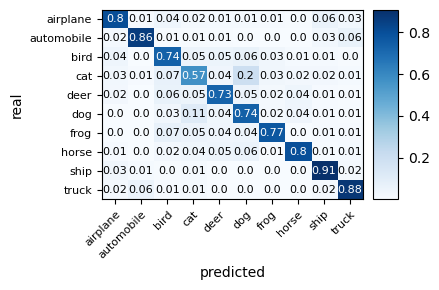

In [9]:
task.draw_confusion_heatmap(confusion_ref).to_matplotlib()
plt.show()

100%|██████████| 78/78 [00:00<00:00, 269.07it/s]


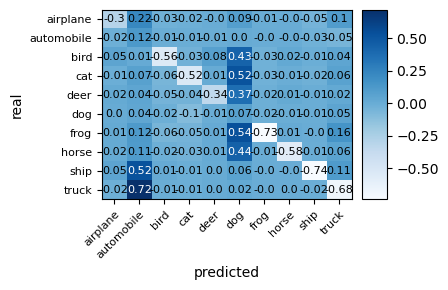

In [10]:
stage = 2
task.model.set_active(stage)
test, b = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid)
confusion = test.confusion.type(torch.float32)
confusion = (confusion / confusion.sum(dim=0, keepdim=True)).transpose(1, 0)
diff = confusion - confusion_ref

task.draw_confusion_heatmap(diff).to_matplotlib()
plt.show()

In [11]:
model_1 = task.model.masks[0]

# Count total parameters (for comparison)
total_params = sum(p.numel() for p in model_1.parameters() if p.requires_grad)
# Count only nonzero parameters
nonzero_params = sum((p > 0).sum().item() for p in model_1.parameters() if p.requires_grad)

print(f"Total parameters:           {total_params:,}")
print(f"Nonzero parameters:         {nonzero_params:,} --- {round(100 * (nonzero_params / total_params), 2)}%")

Total parameters:           390,986
Nonzero parameters:         191,291 --- 48.93%


In [30]:
task.valid_sets

{'iid': <dataset.image.cifar.CIFAR10 at 0x7f1d9c312db0>,
 'train': <dataset.image.cifar.CIFAR10 at 0x7f1dba57d0a0>}

In [32]:
task.prepare_model_for_analysis()

# count = 0
for stage, mask_id in enumerate([-1]+task.mask_classes):
    # if count > 1:
    #     break
    # count += 1
    split = "baseline" if stage==0 else task.train_set.class_names[mask_id]

    task.model.set_active(stage)

    # set = task.create_restricted_train_set([i for i in range(task.train_set.n_classes) if i != mask_id])
    # if mask_id == -1:
    #     include_classes = [i for i in range(task.train_set.n_classes) if i != mask_id]
    # else:
    #     include_classes = [mask_id]

    # set = task.create_restricted_train_set(include_classes)
    # task.create_validate_on_train(set)

    print(f"stage/mask_id: {stage}/{mask_id}")

    model_1 = task.model.masks[stage]
    nonzero_params = sum((p > 0).sum().item() for p in model_1.parameters() if p.requires_grad)

    print(f"Nonzero parameters:   {nonzero_params:,} --- {round(100 * (nonzero_params / total_params), 2)}%")

    # If mask is finished training
    # test, _ = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid)
    # print(f"Self-class accuracy: {test.accuracy}")

    print("#######################")
        

stage/mask_id: 0/-1
Nonzero parameters:   191,291 --- 48.93%
#######################
stage/mask_id: 1/0
Nonzero parameters:   66,865 --- 17.1%
#######################
stage/mask_id: 2/1
Nonzero parameters:   56,225 --- 14.38%
#######################
stage/mask_id: 3/2
Nonzero parameters:   106,555 --- 27.25%
#######################
stage/mask_id: 4/3
Nonzero parameters:   99,378 --- 25.42%
#######################
stage/mask_id: 5/4
Nonzero parameters:   93,032 --- 23.79%
#######################
stage/mask_id: 6/5
Nonzero parameters:   91,449 --- 23.39%
#######################
stage/mask_id: 7/6
Nonzero parameters:   71,290 --- 18.23%
#######################
stage/mask_id: 8/7
Nonzero parameters:   54,893 --- 14.04%
#######################
stage/mask_id: 9/8
Nonzero parameters:   75,065 --- 19.2%
#######################
stage/mask_id: 10/9
Nonzero parameters:   77,146 --- 19.73%
#######################


In [25]:
len(task.valid_sets.iid)

9947

stage/mask_id: 0/-1
Nonzero parameters:   191,291 --- 48.93%


  0%|          | 0/78 [00:00<?, ?it/s]

100%|██████████| 78/78 [00:00<00:00, 251.57it/s]


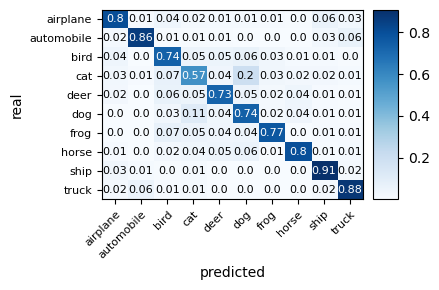

stage/mask_id: 1/0
Nonzero parameters:   66,865 --- 17.1%


100%|██████████| 78/78 [00:00<00:00, 262.33it/s]


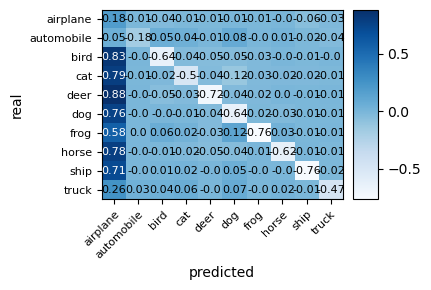

stage/mask_id: 2/1
Nonzero parameters:   56,225 --- 14.38%


100%|██████████| 78/78 [00:00<00:00, 261.43it/s]


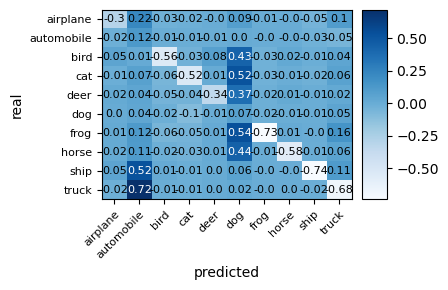

stage/mask_id: 3/2
Nonzero parameters:   106,555 --- 27.25%


100%|██████████| 78/78 [00:00<00:00, 265.79it/s]


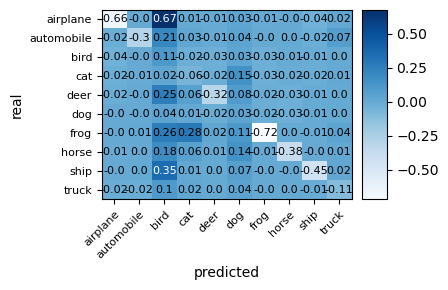

stage/mask_id: 4/3
Nonzero parameters:   99,378 --- 25.42%


100%|██████████| 78/78 [00:00<00:00, 247.43it/s]


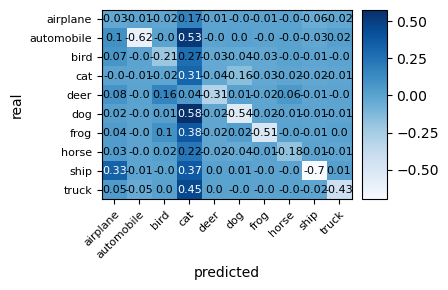

stage/mask_id: 5/4
Nonzero parameters:   93,032 --- 23.79%


100%|██████████| 78/78 [00:00<00:00, 252.08it/s]


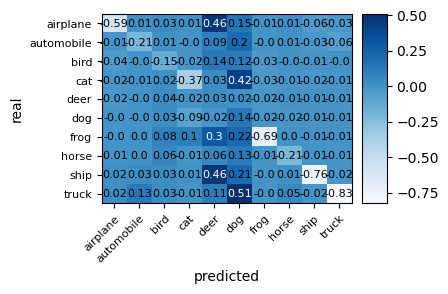

stage/mask_id: 6/5
Nonzero parameters:   91,449 --- 23.39%


100%|██████████| 78/78 [00:00<00:00, 251.84it/s]


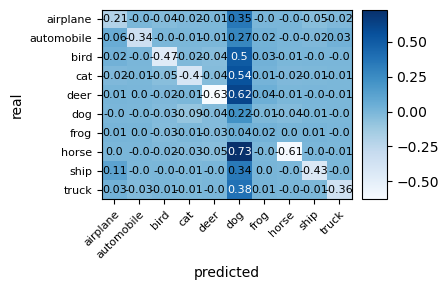

stage/mask_id: 7/6
Nonzero parameters:   71,290 --- 18.23%


100%|██████████| 78/78 [00:00<00:00, 256.06it/s]


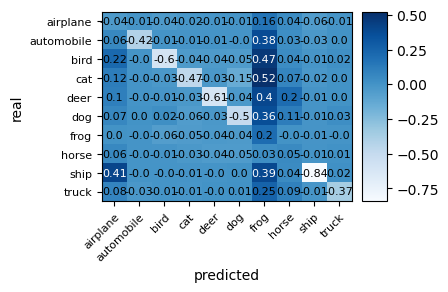

stage/mask_id: 8/7
Nonzero parameters:   54,893 --- 14.04%


100%|██████████| 78/78 [00:00<00:00, 259.85it/s]


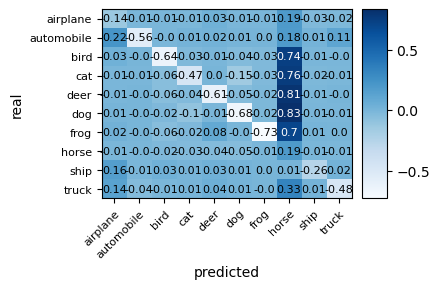

stage/mask_id: 9/8
Nonzero parameters:   75,065 --- 19.2%


100%|██████████| 78/78 [00:00<00:00, 264.06it/s]


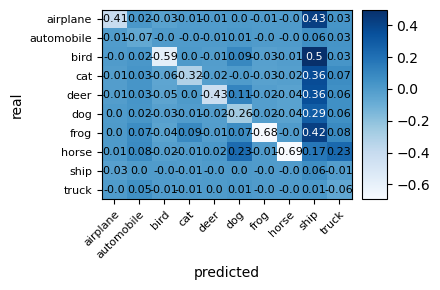

stage/mask_id: 10/9
Nonzero parameters:   77,146 --- 19.73%


100%|██████████| 78/78 [00:00<00:00, 260.03it/s]


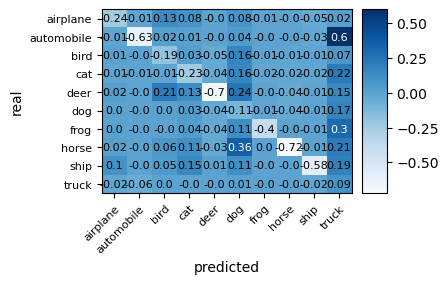

In [31]:
task.prepare_model_for_analysis()


for stage, mask_id in enumerate([-1]+task.mask_classes):
    split = "baseline" if stage==0 else task.train_set.class_names[mask_id]

    task.model.set_active(stage)

    # set = task.create_restricted_train_set([i for i in range(task.train_set.n_classes) if i != mask_id])
    # task.create_validate_on_train(set)

    print(f"stage/mask_id: {stage}/{mask_id}")

    model_1 = task.model.masks[stage]
    nonzero_params = sum((p > 0).sum().item() for p in model_1.parameters() if p.requires_grad)

    print(f"Nonzero parameters:   {nonzero_params:,} --- {round(100 * (nonzero_params / total_params), 2)}%")

    # If mask is finished training
    test, _ = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid)
    confusion = test.confusion.type(torch.float32)
    confusion = (confusion / confusion.sum(dim=0, keepdim=True)).transpose(1, 0)
    # Have a reference mask which is all the classes?
    if stage == 0:
        confusion_ref = confusion
        task.draw_confusion_heatmap(confusion_ref).to_matplotlib()
        plt.show()
    else:
        diff = confusion - confusion_ref
        task.draw_confusion_heatmap(diff).to_matplotlib()
        plt.show()

In [15]:
from pathlib import Path

rundir = "./save/cifar10/export/stage_final_masks/"

In [16]:
p = Path(Path.cwd() / rundir)
p

PosixPath('/home/Raffew/Projects/Csordas_modules/save/cifar10/export/stage_final_masks')

In [17]:
num_folders = len([1 for entry in Path(rundir).iterdir() if entry.is_dir()])
num_folders

11

In [18]:
for stage in range(num_folders):
    weights = [torch.load(w, weights_only=False).reshape(-1) for w in Path().glob(f"{rundir}/stage_{stage}/**/*.pth")]
    print(weights)
    break

[array([ 2.6369717 ,  4.2277794 ,  0.32757622,  3.3867707 ,  2.202412  ,
        2.7907357 ,  3.9601774 ,  3.8849027 , -0.87059575,  3.628717  ,
        4.8582044 ,  3.914536  ,  3.7285867 ,  4.91843   ,  0.96754944,
        3.8703272 ,  4.6419497 ,  2.9565852 ,  5.281751  ,  2.3181372 ,
       -0.9727629 ,  3.207938  ,  4.378098  ,  4.164818  ,  4.1138935 ,
        1.380721  ,  4.4770722 ,  0.7525988 ,  4.090915  ,  5.2594066 ,
        2.1235492 ,  3.7790024 ], dtype=float32), array([  2.7225559 ,   3.02551   ,   2.849883  ,   2.5457292 ,
       -14.275013  ,   2.276333  ,   3.0462253 ,   3.1276858 ,
         1.4251386 ,   2.1693234 ,   2.608265  ,   2.3473783 ,
         1.5338578 ,   2.5995681 ,   1.6134914 ,   3.4293299 ,
         3.0120208 ,   2.8966882 ,   2.6364508 ,   2.8086507 ,
         3.1172192 ,   2.316188  ,   2.3552263 ,   2.4949074 ,
         3.074001  ,   3.0390007 ,   2.8033593 ,   3.5945482 ,
         3.423007  ,   1.5939145 ,   1.5494925 ,   2.4914427 ,
         2.97

In [24]:
for x in task.model.masks[0].parameters():
    print(x)

Parameter containing:
tensor([ 2.6370,  4.2278,  0.3276,  3.3868,  2.2024,  2.7907,  3.9602,  3.8849,
        -0.8706,  3.6287,  4.8582,  3.9145,  3.7286,  4.9184,  0.9675,  3.8703,
         4.6419,  2.9566,  5.2818,  2.3181, -0.9728,  3.2079,  4.3781,  4.1648,
         4.1139,  1.3807,  4.4771,  0.7526,  4.0909,  5.2594,  2.1235,  3.7790],
       device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[[[  2.7226,   3.0255,   2.8499],
          [  2.5457, -14.2750,   2.2763],
          [  3.0462,   3.1277,   1.4251]],

         [[  2.1693,   2.6083,   2.3474],
          [  1.5339,   2.5996,   1.6135],
          [  3.4293,   3.0120,   2.8967]],

         [[  2.6365,   2.8087,   3.1172],
          [  2.3162,   2.3552,   2.4949],
          [  3.0740,   3.0390,   2.8034]]],


        [[[  3.5945,   3.4230,   1.5939],
          [  1.5495,   2.4914,   2.9793],
          [  2.3863,   2.9125,   1.7734]],

         [[  3.6370,   3.6746,   1.5607],
          [  1.9315,   3.3054,   2.

# NOTES

When looking at the 11 "masks", the first mask is a mask made to "keep" the output and last layer. Look into "def class_removal_init_masks_and_optim" to see the usage. 

Only dataloaders have a random seed "set", but that is still randomized.

They loos quite a lot of performance in their subnetworks, if i understand their confusion matrices correctly.

Masks are initialized as "2.0" --> All masks start out the same.

The normalize the data with these tensor values:

MEAN:

    array([[[125.3069 ]],

        [[122.95015]],

        [[113.866  ]]], dtype=float32)

STD:

    array([[[62.992565]],

       [[62.08881 ]],

       [[66.70408 ]]], dtype=float32)

They never change the underlying model parameter values, they only do some "masking magic"